## life cycle of data Science
1. data collection (from company, 3rd  party API,surveys)
2. Featuure Engineering
   i. handle missing value

## type of missing Data:
missging completely at random:
A dataset is MCAR if the probability that a value is missing is independent of:
1. the value itself, and
2. all other variables in the dataset.
   
How to Handle MCAR
✔ Mean / Median / Mode imputation
✔ Dropping missing rows
✔ Simple imputation works well

In [4]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
df=pd.read_csv('titanic.csv')

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [39]:
null_feature = [feature for feature in df.columns if df[feature].isnull().sum()>1]
null_feature

['Age', 'Cabin', 'Embarked']

In [40]:
for item in null_feature:
    print(f'{item} : {df[item].isnull().sum()}')

Age : 177
Cabin : 687
Embarked : 2


In [13]:
np.ndim(df)
#shows the dimension

2

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [43]:
df.shape

(891, 12)

In [45]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


### Missing Data not at randomly

In [46]:
df['Cabin_null']=np.where(df['Cabin'].isnull(),1,0)

In [47]:
df['Cabin'].isnull().mean() 
# same mean value for df['canin_null']
# means 77.1% null value

np.float64(0.7710437710437711)

In [49]:
df[['Cabin','Cabin_null']].head(10)

,Cabin,Cabin_null
0,NaN,1
1,C85,0
2,NaN,1
3,C123,0
4,NaN,1
5,NaN,1
6,E46,0
7,NaN,1
8,NaN,1
9,NaN,1


In [51]:
df.groupby(['Survived'])['Cabin_null'].mean()

Survived
0    0.876138
1    0.602339
Name: Cabin_null, dtype: float64

In [52]:
df['Survived'].unique()

array([0, 1])

### Missing Not  At Random(MNR)

All types of  technique to handle missing data:
1. mean/median/mode replacement
2. random sample Imputation
3. capturing nan Value with a New Feature
4. End of distribution Imputation
5. Arbitary imputation
6. frequent categories imputation

#### 1. mean median and mode imputation
it has assumption thatthe data are missing completely at random(MCAR)
solve this by replacing NaN with most frequent occurance 

In [53]:
df=pd.read_csv('titanic.csv',usecols=['Age','Survived','Fare'])

In [54]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [55]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [56]:
def fill_nan(df,feature,median):
    df[feature + '_median']=df[feature].fillna(median)

In [57]:
median=df.Age.median()
median

np.float64(28.0)

In [58]:
fill_nan(df,'Age',median)
df.head()

,Survived,Age,Fare,Age_median
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [60]:
df[df['Age'].isnull()].head()
# to ensure

,Survived,Age,Fare,Age_median
5,0,NaN,8.4583,28.0
17,1,NaN,13.0000,28.0
19,1,NaN,7.2250,28.0
26,0,NaN,7.2250,28.0
28,1,NaN,7.8792,28.0


In [63]:
df['Age'].std()   #df['age'].describe()

np.float64(14.526497332334042)

In [64]:
df['Age_median'].std()    #df['Age_median'].describe()

np.float64(13.019696550973201)

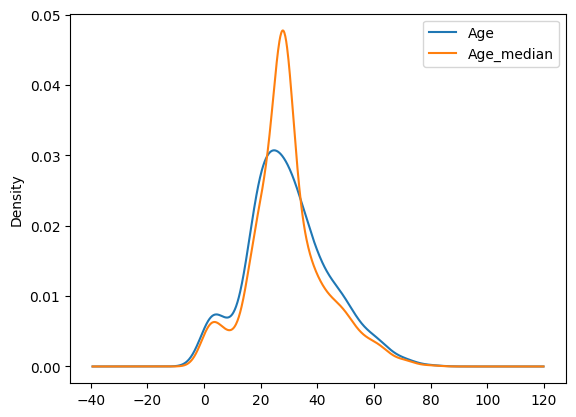

In [73]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['Age'].plot(kind='kde')
df['Age_median'].plot(kind='kde')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

#### Now Advantage and Disadvantage of this:
Advantage
1. Easy to implement (robust ro outlier).
2. Faster way to obtain a complete dataset.

Disadvantage
1. distoration in variance of data.
2. imbalance dataset